# Feature Engineering Laboratory

This notebook prototypes the core transformations to be used in Step 2 of our pipeline before scripting them.


## 1. Setup & Data Loading
We load the raw data via the modular `data_ingestion` script and define our testing configurations here.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
import sys
from pathlib import Path

# Add root folder to sys.path so we can import src
sys.path.append('..')

from src.data_ingestion import load_and_merge_zone
from src.constants import TARGET_COL

# Load configuration
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# --- CONFIGURATION ---
TARGET_ZONE = 'DE'     # Domestic Zone to predict
NEIGHBOR_ZONE = 'AT'   # Neighboring Zone to test adding to the Greedy Selector
MAD_WINDOW = '24h'     # Rolling window for Spike Detection
MAD_Z = 3.0            # Number of Absolute Deviations to clip
LAGS = [24, 48, 168]   # Autoregressive Lag Hours
# ---------------------

df_de = load_and_merge_zone(TARGET_ZONE, f"../{config['data']['raw_dir']}")

print(f"Base Data Shape ({TARGET_ZONE}): {df_de.shape}")
df_de.head()


Base Data Shape (DE): (17544, 23)


,Spot_Price,Total_Load,BIOMASS,COAL-DERVIED GAS,FOSSIL-GAS,GEOTHERMAL,HARD-COAL,HYDRO-PUMPED-STORAGE,HYDRO-ROR,HYDRO-WATER-RESERVOIR,...,OTHER,OTHER-RENEWABLE,SOLAR,WASTE,WIND-OFFSHORE,WIND-ONSHORE,Renewables,Baseload,Dispatchable,Residual_Load
time,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,0.01,39221.140,3884.4100,418.825,2824.4625,28.5025,1854.4850,415.7300,1837.7800,143.9975,...,152.3825,112.7000,2.9625,569.4475,5345.7375,29493.0600,34841.7600,5722.1900,8051.6375,4379.3800
2024-01-01 01:00:00+00:00,0.00,38238.590,3868.7750,419.975,2852.3000,28.1250,1828.8300,403.4225,1843.7800,157.9975,...,152.3500,112.6575,2.9325,562.0550,5188.5650,29573.3025,34764.8000,5712.5550,8054.8125,3473.7900
2024-01-01 02:00:00+00:00,-0.01,37508.440,3844.0375,426.775,2874.2500,28.2775,1817.6675,325.6000,1841.8375,168.6600,...,152.4175,112.9650,3.1825,572.6450,4674.1150,29037.5550,33714.8525,5685.8750,8084.9075,3793.5875
2024-01-01 03:00:00+00:00,-0.03,37134.775,3849.3975,402.700,2856.9900,27.9075,1832.8375,177.6000,1822.1575,210.0050,...,152.3100,112.9600,2.7675,563.1950,4439.3450,28969.9675,33412.0800,5671.5550,8083.5350,3722.6950
2024-01-01 04:00:00+00:00,-0.02,37437.265,3887.0375,395.325,2895.1075,27.0950,1831.4775,179.9950,1826.3450,214.2200,...,152.3850,112.7350,3.0625,561.6300,4624.6850,29096.5600,33724.3075,5713.3825,8125.6000,3712.9575


## 2. Spike Filtering (MAD)
Extreme spot prices distort loss functions. We apply a rolling Median Absolute Deviation (MAD) filter *before* lagging to cap outliers natively.


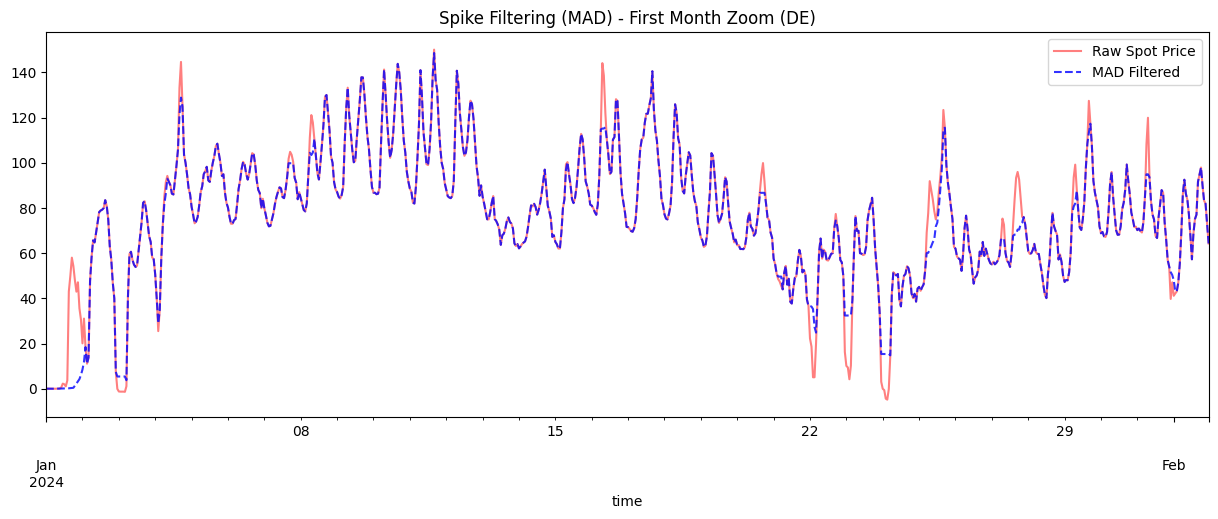

In [9]:
def apply_rolling_mad_filter(series, window='24h', z=3):
    rolling_median = series.rolling(window).median()
    
    # Calculate rolling MAD
    # rolling.apply is slow, but for 17k rows it's acceptable.
    mad = series.rolling(window).apply(lambda x: np.median(np.abs(x - np.median(x))), raw=True)
    
    upper_bound = rolling_median + z * mad
    lower_bound = rolling_median - z * mad
    
    # Clip values
    return series.clip(lower=lower_bound, upper=upper_bound)

# Apply to Spot Price
df_de['Spot_Price_Filtered'] = apply_rolling_mad_filter(df_de[TARGET_COL], window=MAD_WINDOW, z=MAD_Z)

# Visualize the effect
fig, ax = plt.subplots(figsize=(15, 5))
df_de[TARGET_COL].loc['2024-01-01':'2024-02-01'].plot(ax=ax, label='Raw Spot Price', alpha=0.5, color='red')
df_de['Spot_Price_Filtered'].loc['2024-01-01':'2024-02-01'].plot(ax=ax, label='MAD Filtered', alpha=0.8, color='blue', linestyle='--')
ax.legend()
ax.set_title(f"Spike Filtering (MAD) - First Month Zoom ({TARGET_ZONE})")
plt.show()


## 3. Deterministic Features
Extract cyclical time attributes (Hour, Day, Month) to capture seasonality.


In [10]:
def add_deterministic_features(df):
    df_feat = df.copy()
    df_feat['Hour'] = df_feat.index.hour
    df_feat['DayOfWeek'] = df_feat.index.dayofweek
    df_feat['Month'] = df_feat.index.month
    return df_feat

df_de = add_deterministic_features(df_de)
df_de[['Spot_Price_Filtered', 'Hour', 'DayOfWeek', 'Month']].head()


,Spot_Price_Filtered,Hour,DayOfWeek,Month
time,,,,
2024-01-01 00:00:00+00:00,0.01,0,0,1
2024-01-01 01:00:00+00:00,0.00,1,0,1
2024-01-01 02:00:00+00:00,-0.01,2,0,1
2024-01-01 03:00:00+00:00,-0.03,3,0,1
2024-01-01 04:00:00+00:00,-0.02,4,0,1


## 4. Autoregressive Features (Lags)
Generate precise delay blocks configured in the first cell, constructed WITHOUT lookahead bias.


In [11]:
def add_lags(df, columns, lags=[24, 48, 168]):
    df_feat = df.copy()
    for col in columns:
        for lag in lags:
            df_feat[f'{col}_lag_{lag}'] = df_feat[col].shift(lag)
    return df_feat

lag_targets = ['Spot_Price_Filtered', 'Residual_Load']
df_de = add_lags(df_de, lag_targets, lags=LAGS)

# Drop NaN rows caused by the largest shift (e.g. 168h drops first 7 days)
df_de = df_de.dropna()

print(f"Shape after lag generation and dropna: {df_de.shape}")
df_de[[TARGET_COL, f'Spot_Price_Filtered_lag_{LAGS[0]}', f'Residual_Load_lag_{LAGS[-1]}']].head()


Shape after lag generation and dropna: (735, 33)


,Spot_Price,Spot_Price_Filtered_lag_24,Residual_Load_lag_168
time,,,
2024-01-08 00:00:00+00:00,84.32,79.82,4379.3800
2024-01-08 01:00:00+00:00,81.82,76.76,3473.7900
2024-01-08 02:00:00+00:00,79.11,73.46,3793.5875
2024-01-08 03:00:00+00:00,78.48,71.86,3722.6950
2024-01-08 04:00:00+00:00,82.10,72.08,3712.9575


## 5. The Greedy Algorithm Prototype
We form a Walk-Forward validation loop using LightGBM comparing the target model vs a combined feature bundle model.


In [12]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor

# Define Base Features Dynamically from configured components
base_features = ['Hour', 'DayOfWeek', 'Month']
for col in lag_targets:
    for lag in LAGS:
        base_features.append(f'{col}_lag_{lag}')

target = TARGET_COL

def walk_forward_cv(df, features, target, splits=5):
    tscv = TimeSeriesSplit(n_splits=splits)
    maes = []
    
    # Needs to be sorted chronologically
    df_sorted = df.sort_index()
    X = df_sorted[features]
    y = df_sorted[target]
    
    model = LGBMRegressor(n_estimators=50, random_state=42, n_jobs=-1, verbose=-1)
    
    for train_index, test_index in tscv.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        maes.append(mean_absolute_error(y_test, preds))
        
    return np.mean(maes)

# 1. Evaluate Base Model
mae_base = walk_forward_cv(df_de, base_features, target)
print(f"Base {TARGET_ZONE} Model MAE: {mae_base:.3f} EUR/MWh")

# 2. Extract Neighboring Features
df_neighbor = load_and_merge_zone(NEIGHBOR_ZONE, f"../{config['data']['raw_dir']}")

# Apply same transformations to neighbor
df_neighbor['Spot_Price_Filtered'] = apply_rolling_mad_filter(df_neighbor[TARGET_COL], window=MAD_WINDOW, z=MAD_Z)
df_neighbor_lagged = add_lags(df_neighbor, lag_targets, lags=LAGS)

# To avoid suffix collision, we rename columns with zone prefix
neighbor_cols = [c for c in df_neighbor_lagged.columns if 'lag' in c]
df_neighbor_lagged = df_neighbor_lagged[neighbor_cols].rename(columns=lambda x: f"{NEIGHBOR_ZONE}_{x}")

# Join back to target zone dataset
df_bundle = df_de.join(df_neighbor_lagged, how='inner').dropna()

# Bundle Features
bundle_features = base_features + list(df_neighbor_lagged.columns)

mae_bundle = walk_forward_cv(df_bundle, bundle_features, target)
print(f"Bundle ({TARGET_ZONE} + {NEIGHBOR_ZONE} lags) MAE: {mae_bundle:.3f} EUR/MWh")

if mae_bundle < mae_base:
    print(f"\n>>> The Greedy Selector effectively accepts {NEIGHBOR_ZONE} as a neighboring feature!")
else:
    print(f"\n>>> The Greedy Selector rejects {NEIGHBOR_ZONE}.")



Base DE Model MAE: 22.045 EUR/MWh
Bundle (DE + AT lags) MAE: 21.897 EUR/MWh

>>> The Greedy Selector effectively accepts AT as a neighboring feature!
